In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
metrics_dir=os.path.join(os.getcwd(),"metrics")
# --- LOAD THE .pkl FILE GENERATED PREVIOUSLY ---
adapt=[0,120,20,2]
test_ds_b4=False


combined_results=[]
for a in adapt:
    if test_ds_b4:
        identifier=f"testing_dsb4_adaptable{a}" if a > 0 else "testing_dsb4"
    else:
        identifier=f"30000_1000_100_adaptable{a}" if a > 0 else "30000_1000_100"
        # identifier="1000_200_median"
    filename = f"channel_kappa_by_network_{identifier}.csv"
    path = os.path.join(metrics_dir, filename)

    if os.path.exists(path):
        df = pd.read_csv(path)
        df["Adapt"] = a  # Add a column to identify the condition
        combined_results.append(df)
        print(f"Loaded: {filename}")
    else:
        print(f"Missing: {filename}")

# Combine all into one DataFrame
all_results_df = pd.concat(combined_results, ignore_index=True)

Loaded: channel_kappa_by_network_30000_1000_100.csv
Loaded: channel_kappa_by_network_30000_1000_100_adaptable120.csv
Loaded: channel_kappa_by_network_30000_1000_100_adaptable20.csv
Loaded: channel_kappa_by_network_30000_1000_100_adaptable2.csv


In [14]:
def plot_cohen_kappa_by_adapt(df, adapt_col="Adapt", dataset_col="Dataset", kappa_col="Cohen_Kappa"):
    # Optional: simplify dataset names if needed (adjust regex to your dataset naming)
    df = df.copy()
    df[dataset_col] = df[dataset_col].str.extract(r"(Amigo|Dlx|Som|Thy)", expand=False)
    
    adapt_values = sorted(df[adapt_col].unique())
    datasets = sorted(df[dataset_col].dropna().unique())

    width = 0.15  # box width
    colors = plt.cm.viridis_r(np.linspace(0.2, 0.8, len(adapt_values)))

    fig, ax = plt.subplots(figsize=(10, 6))

    positions = []
    data = []

    for i, dataset in enumerate(datasets):
        for j, adapt in enumerate(adapt_values):
            subset = df[(df[dataset_col] == dataset) & (df[adapt_col] == adapt)]
            y_vals = subset[kappa_col].values
            pos = i * (len(adapt_values) + 1) + j  # spacing
            data.append(y_vals)
            positions.append(pos)

    # Plot boxes
    for i, (vals, pos) in enumerate(zip(data, positions)):
        color = colors[i % len(adapt_values)]
        bplot = ax.boxplot(vals, positions=[pos], widths=width, patch_artist=True,
                           showfliers=False, medianprops=dict(color='black'))
        for patch in bplot['boxes']:
            patch.set_facecolor(color)

    # X-axis setup
    xticks = [i * (len(adapt_values) + 1) + (len(adapt_values) - 1) / 2 for i in range(len(datasets))]
    ax.set_xticks(xticks)
    ax.set_xticklabels(datasets, fontsize=12)

    # Legend
    legend_labels = [f"{a}" for a in adapt_values]
    legend_patches = [plt.Line2D([0], [0], color='white', marker='s', markersize=10,
                                 markerfacecolor=c, label=l) for c, l in zip(colors, legend_labels)]
    ax.legend(handles=legend_patches, title="Adapt Condition", fontsize=11, title_fontsize=12)

    # Labels and title
    ax.set_ylabel("Cohen's Kappa", fontsize=12)
    ax.set_title("Cohen's Kappa by Dataset and Adapt Condition", fontsize=14)
    ax.set_ylim(-0.5, 1)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

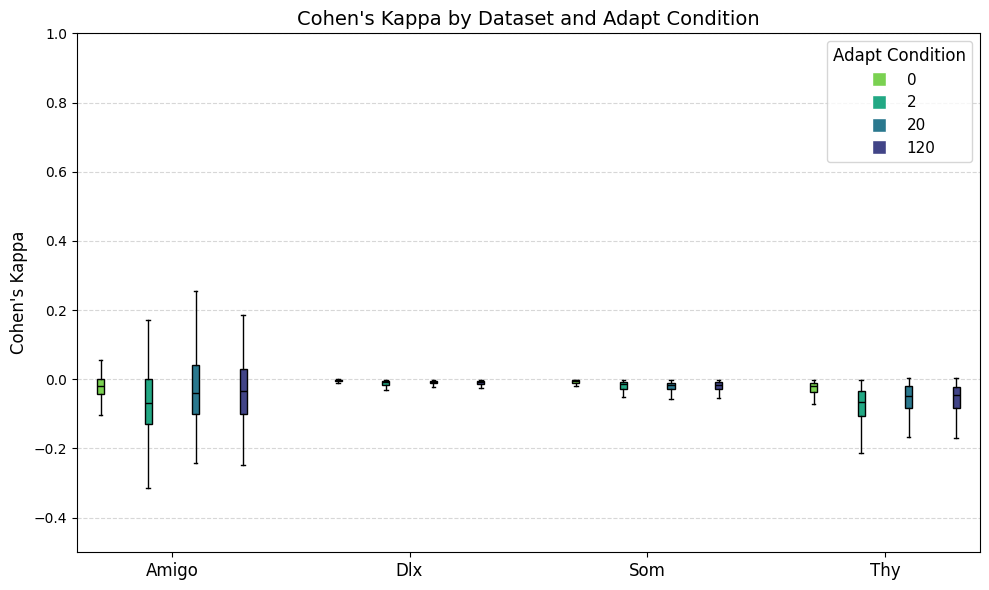

In [15]:
plot_cohen_kappa_by_adapt(all_results_df)


In [21]:
def make_kappa_summary_table_with_overall_and_peak(df, adapt_col="Adapt", dataset_col="Dataset", kappa_col="Cohen_Kappa"):
    import pandas as pd
    import numpy as np

    df = df.copy()
    df[dataset_col] = df[dataset_col].str.extract(r"(Amigo|Dlx|Som|Thy)", expand=False)

    # Compute mean and std per dataset and adapt
    summary = (
        df.groupby([dataset_col, adapt_col])[kappa_col]
        .agg(['mean', 'std'])
        .reset_index()
    )
    summary['formatted'] = summary.apply(
        lambda row: f"{row['mean']:.3f} ± {row['std']:.3f}", axis=1
    )

    # Compute overall (mean of means across datasets per adapt)
    overall = (
        df.groupby([adapt_col])[kappa_col]
        .agg(['mean', 'std'])
        .reset_index()
    )
    overall[dataset_col] = 'Overall'
    overall['formatted'] = overall.apply(
        lambda row: f"{row['mean']:.3f} ± {row['std']:.3f}", axis=1
    )

    # Combine
    full = pd.concat([summary, overall], ignore_index=True)

    # Find global max mean value and mark it with a star
    peak_idx = full['mean'].idxmax()
    # full.at[peak_idx, 'formatted'] += " ⭐"

    # Pivot to table
    table = full.pivot(index=dataset_col, columns=adapt_col, values='formatted')

    # Sort rows and columns
    desired_order = ["Amigo", "Dlx", "Som", "Thy", "Overall"]
    table = table.reindex(desired_order)
    table = table[sorted(table.columns)]

    return table


In [22]:
make_kappa_summary_table_with_overall_and_peak(all_results_df)    

Adapt,0,2,20,120
Dataset,,,,
Amigo,-0.024 ± 0.057,-0.083 ± 0.159,-0.037 ± 0.145,-0.041 ± 0.143
Dlx,-0.005 ± 0.007,-0.013 ± 0.014,-0.012 ± 0.013,-0.012 ± 0.013
Som,-0.009 ± 0.012,-0.024 ± 0.031,-0.026 ± 0.028,-0.025 ± 0.027
Thy,-0.031 ± 0.035,-0.091 ± 0.090,-0.072 ± 0.078,-0.072 ± 0.078
Overall,-0.017 ± 0.036,-0.053 ± 0.099,-0.037 ± 0.086,-0.037 ± 0.086
